##############################################################
# Project:
# Privacy-Preserving Explainable AI Framework
# for Predicting Anxiety Risk Among University Students Reachy mini Robot 
Notebook 1
Data Loading
Data Cleaning
Exploratory Data Analysis (EDA)
Data Preprocessing
##############################################################

# Import Libraries and load dataset

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

plt.style.use("ggplot")

print("="*60)
print("Libraries Imported Successfully")
print("="*60)


Libraries Imported Successfully


In [4]:
df = pd.read_csv("/kaggle/input/datasets/digrok/anxiety-robot/Anxiety.csv")
print("="*70)
print("Dataset Loaded Successfully")
print("="*70)

print("Dataset Shape : ",df.shape)

Dataset Loaded Successfully
Dataset Shape :  (2028, 16)


In [5]:
df.head()

,Age,Gender,University,Department,Academic Year,Current CGPA,Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,Anxiety Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,2,2,3,2,2,2,2,15,Severe Anxiety
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,1,2,2,1,1,3,2,12,Moderate Anxiety
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,0,0,0,0,0,Minimal Anxiety
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,2,1,1,1,2,1,2,10,Moderate Anxiety
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3,0,3,3,1,1,3,14,Moderate Anxiety


In [6]:
df.head()
df.tail()
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,2028,5,18-22,1304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,2028,3,Male,1405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
University,2028,15,"Independent University, Bangladesh (IUB)",532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,2028,12,Engineering - CS / CSE / CSC / Similar to CS,1409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Year,2028,5,First Year or Equivalent,601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current CGPA,2028,6,3.00 - 3.39,583,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Did you receive a waiver or scholarship at your university?,2028,2,No,1602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",2028.0,NaN,NaN,NaN,1.778107,0.952277,0.0,1.0,2.0,3.0,3.0
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",2028.0,NaN,NaN,NaN,1.634122,1.02762,0.0,1.0,2.0,3.0,3.0
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",2028.0,NaN,NaN,NaN,1.754438,0.996221,0.0,1.0,2.0,3.0,3.0


# Preprocess data

In [7]:
print("="*60)
print("Column Names")
print("="*60)

for col in df.columns:
    print(col)
print("="*60)
print("Checking Missing Values")
print("="*60)

missing=df.isnull().sum()

missing

Column Names
Age
Gender
University
Department
Academic Year
Current CGPA
Did you receive a waiver or scholarship at your university?
1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? 
2. In a semester, how often have you been unable to stop worrying about your academic affairs? 
3. In a semester, how often have you had trouble relaxing due to academic pressure? 
4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?
5. In a semester, how often have you worried too much about academic affairs? 
6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?
7. In a semester, how often have you felt afraid, as if something awful might happen?
Anxiety Value
Anxiety Label
Checking Missing Values


Age                                                                                                             0
Gender                                                                                                          0
University                                                                                                      0
Department                                                                                                      0
Academic Year                                                                                                   0
Current CGPA                                                                                                    0
Did you receive a waiver or scholarship at your university?                                                     0
1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?                      0
2. In a semester, how often have you been unable to stop worrying about your academic af

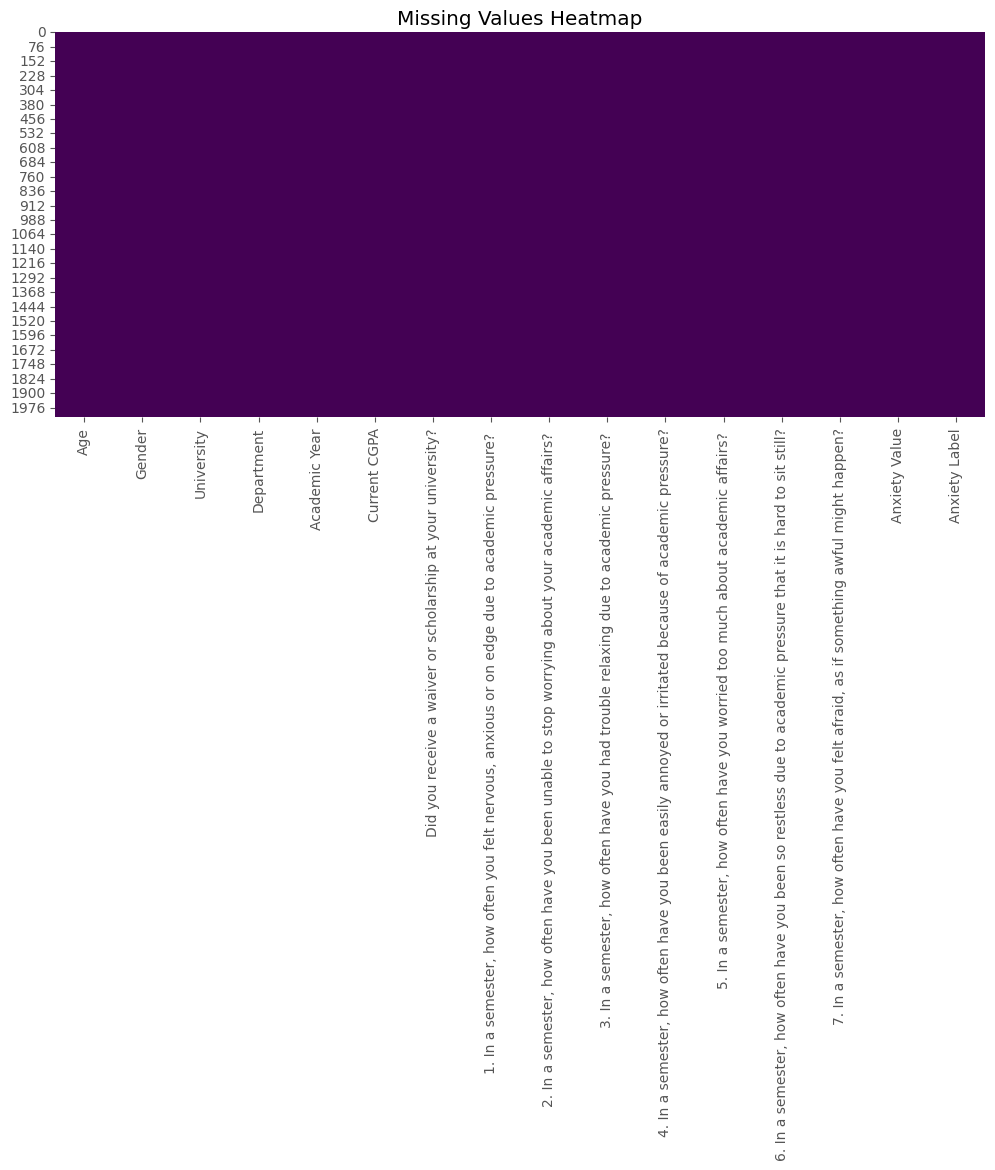

In [8]:
plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [9]:
print("="*60)
print("Duplicate Records")
print("="*60)

duplicates=df.duplicated().sum()

print("Total Duplicate Rows =",duplicates)
if duplicates>0:

    df=df.drop_duplicates()

    print("Duplicates Removed Successfully")

else:

    print("No Duplicate Rows Found")

Duplicate Records
Total Duplicate Rows = 65
Duplicates Removed Successfully


In [10]:
print("="*60)
print("Dataset Shape After Cleaning")
print("="*60)

print(df.shape)

Dataset Shape After Cleaning
(1963, 16)


In [11]:
categorical=[]

numerical=[]

for col in df.columns:

    if df[col].dtype=="object":

        categorical.append(col)

    else:

        numerical.append(col)

print("Categorical Columns")

print(categorical)

print()

print("Numerical Columns")

print(numerical)

Categorical Columns
['Age', 'Gender', 'University', 'Department', 'Academic Year', 'Current CGPA', 'Did you receive a waiver or scholarship at your university?', 'Anxiety Label']

Numerical Columns
['1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ', '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ', '3. In a semester, how often have you had trouble relaxing due to academic pressure? ', '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?', '5. In a semester, how often have you worried too much about academic affairs? ', '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?', '7. In a semester, how often have you felt afraid, as if something awful might happen?', 'Anxiety Value']


In [12]:
print("="*60)
print("Unique Values")
print("="*60)

for col in categorical:

    print("\n",col)

    print(df[col].value_counts())

print("="*60)
print("Target Variable Distribution")
print("="*60)

df["Anxiety Label"].value_counts()

Unique Values

 Age
Age
18-22       1256
23-26        675
27-30         25
Below 18       4
Above 30       3
Name: count, dtype: int64

 Gender
Gender
Male                 1351
Female                602
Prefer not to say      10
Name: count, dtype: int64

 University
University
Independent University, Bangladesh (IUB)                      507
American International University Bangladesh (AIUB)           484
Islamic University of Technology (IUT)                        259
Dhaka University (DU)                                         199
Dhaka University of Engineering and Technology (DUET)         158
North South University (NSU)                                   87
Bangladesh University of Engineering and Technology (BUET)     63
Patuakhali Science and Technology University                   49
East West University (EWU)                                     41
Rajshahi University of Engineering and Technology (RUET)       31
Rajshahi University (RU)                                     

Anxiety Label
Severe Anxiety      706
Moderate Anxiety    617
Mild Anxiety        485
Minimal Anxiety     155
Name: count, dtype: int64

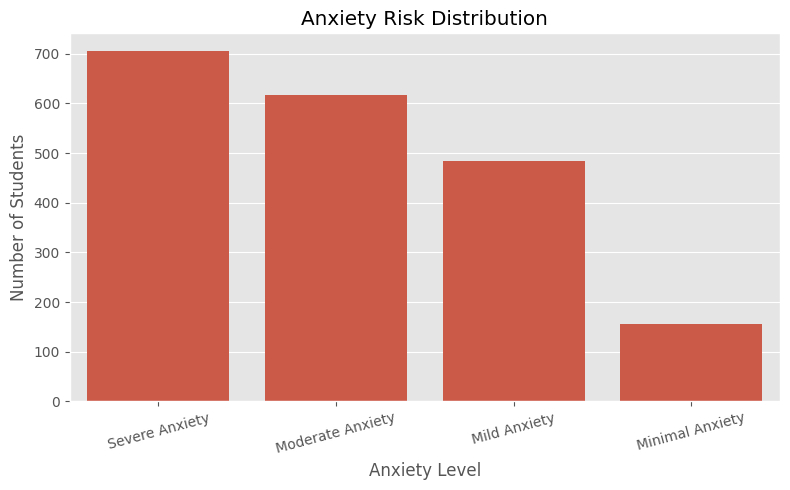

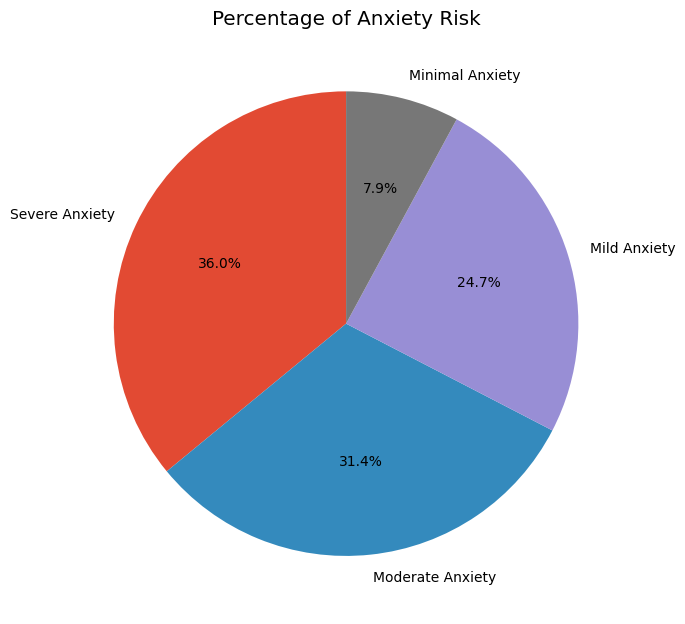

ANXIETY RISK DISTRIBUTION SUMMARY
Rows      : 1963
Columns   : 16
Numerical : 8
Categorical: 8

Anxiety Categories:
Anxiety Label
Severe Anxiety      706
Moderate Anxiety    617
Mild Anxiety        485
Minimal Anxiety     155
Name: count, dtype: int64

Percentage Distribution:
Anxiety Label
Severe Anxiety      35.97
Moderate Anxiety    31.43
Mild Anxiety        24.71
Minimal Anxiety      7.90
Name: count, dtype: float64


In [13]:
# ============================================================
# ANXIETY RISK DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Get Anxiety Label distribution
risk = df["Anxiety Label"].value_counts()

# ------------------------------------------------------------
# 1. Count Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Anxiety Label",
    order=risk.index
)

plt.title("Anxiety Risk Distribution")
plt.xlabel("Anxiety Level")
plt.ylabel("Number of Students")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Percentage Pie Chart
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.pie(
    risk.values,
    labels=risk.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Anxiety Risk")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Distribution Summary
# ------------------------------------------------------------

print("=" * 60)
print("ANXIETY RISK DISTRIBUTION SUMMARY")
print("=" * 60)

print("Rows      :", df.shape[0])
print("Columns   :", df.shape[1])
print("Numerical :", len(numerical))
print("Categorical:", len(categorical))

print("\nAnxiety Categories:")
print(risk)

print("\nPercentage Distribution:")
print((risk / len(df) * 100).round(2))

# Exploratory Data Analysis (EDA)

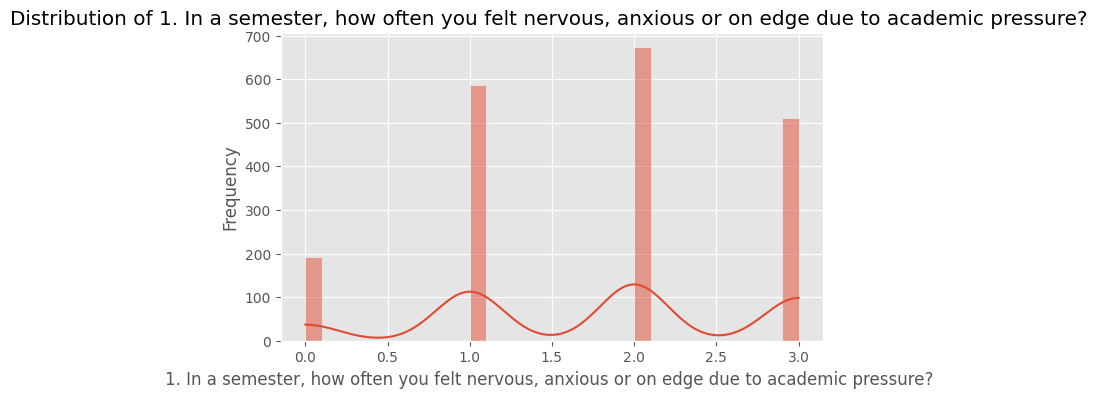

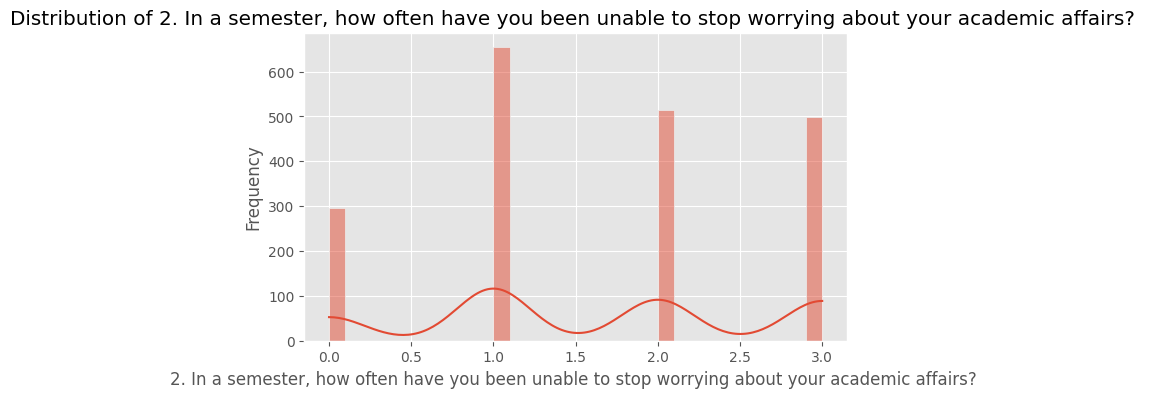

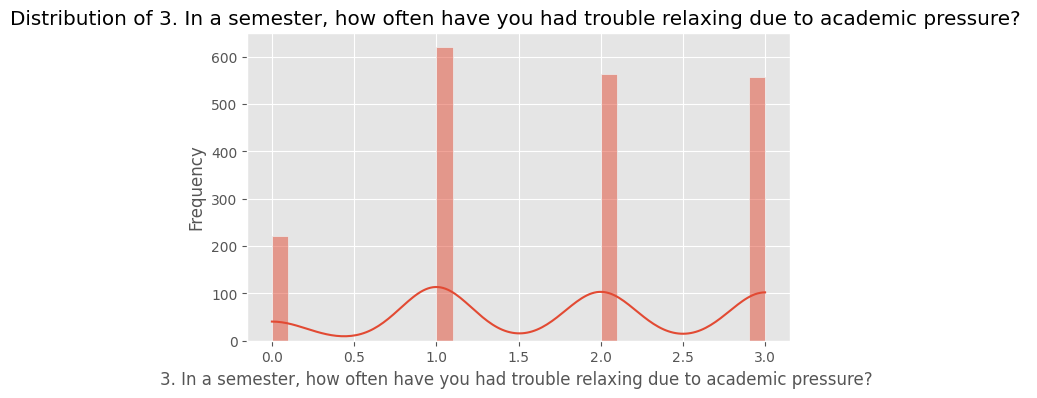

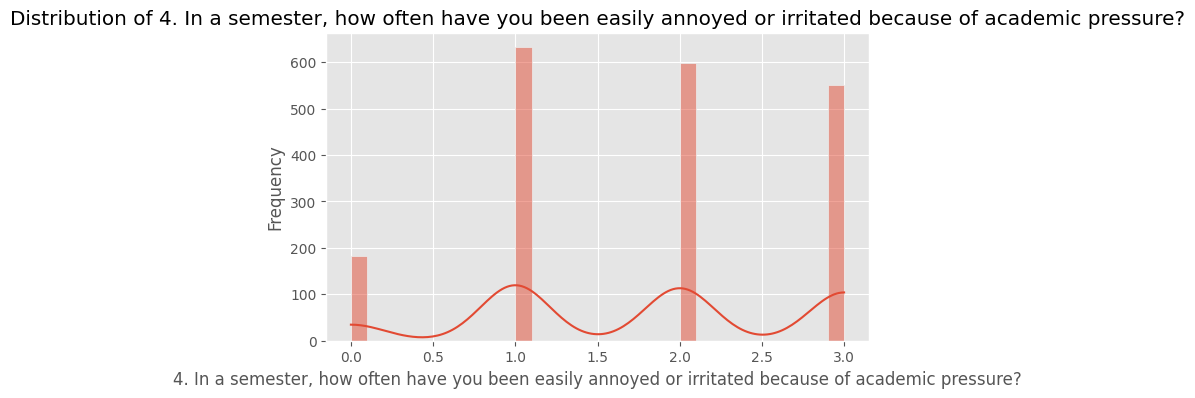

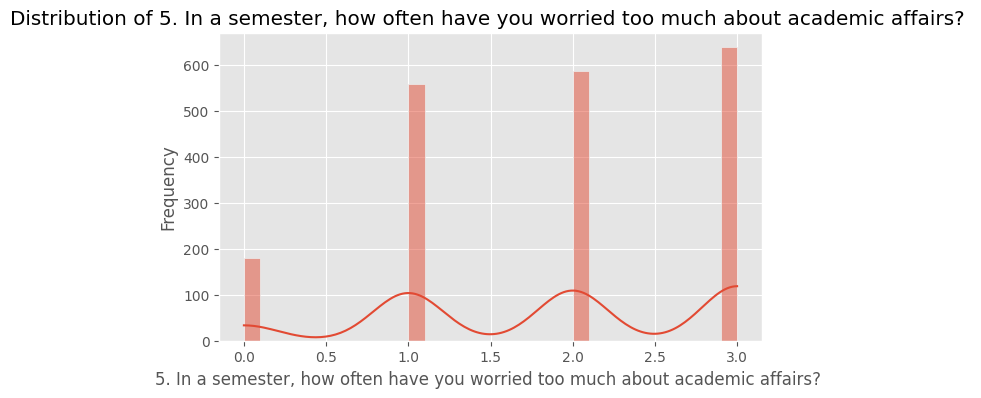

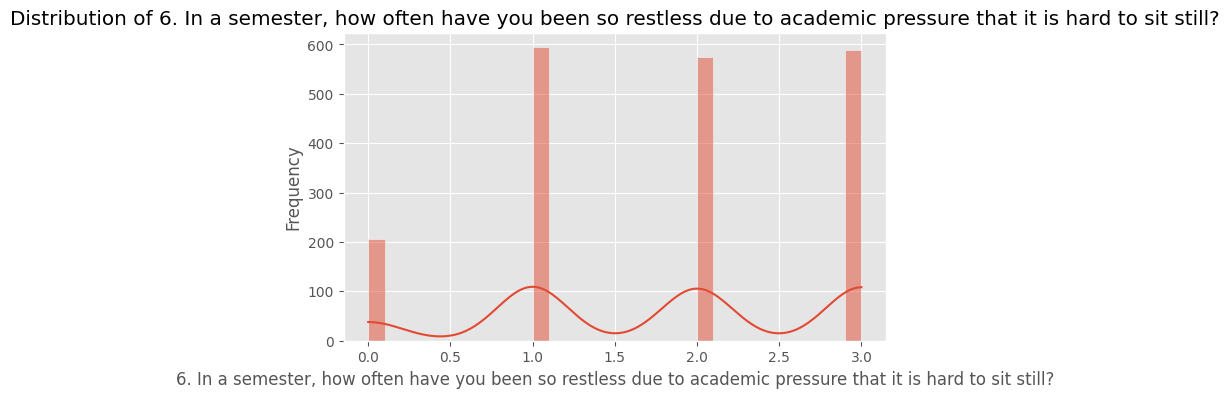

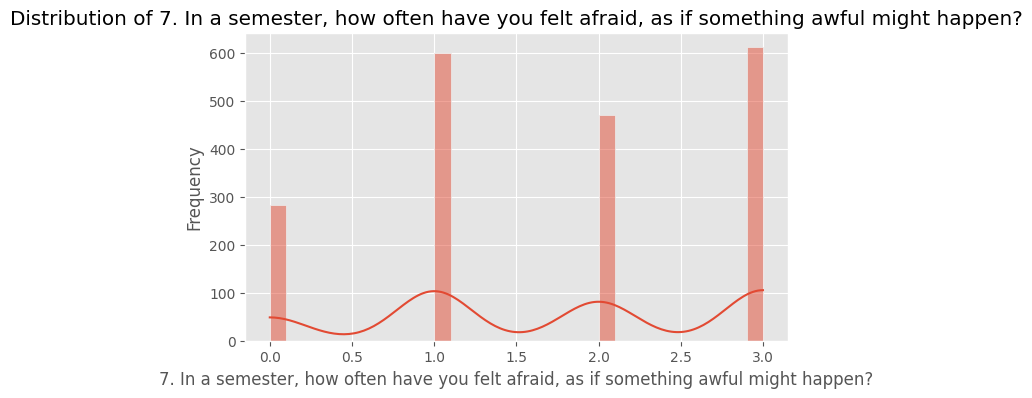

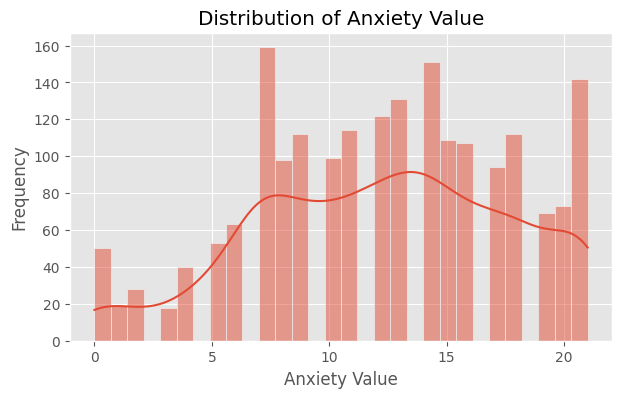

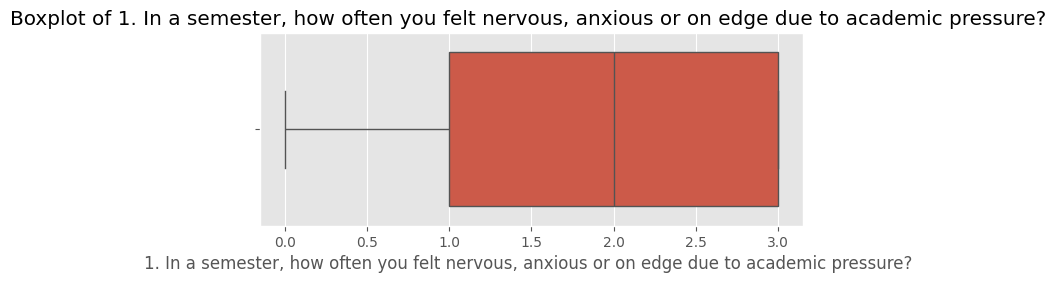

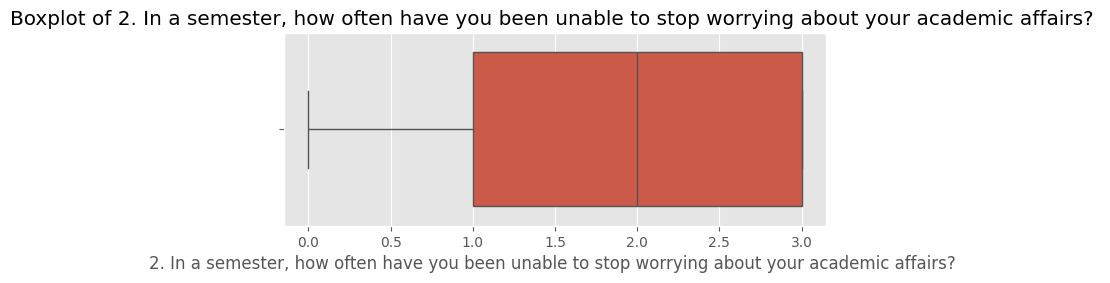

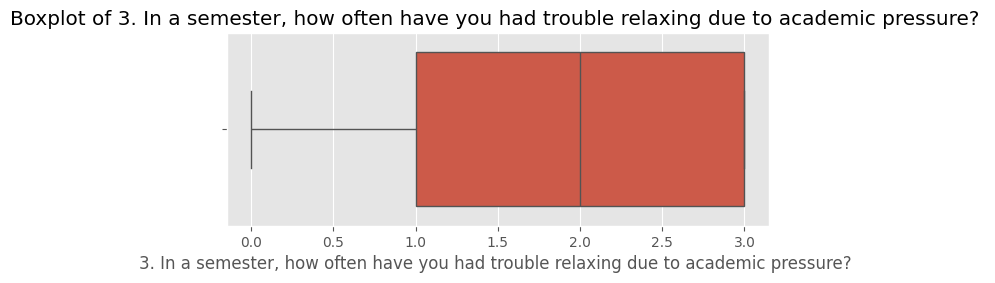

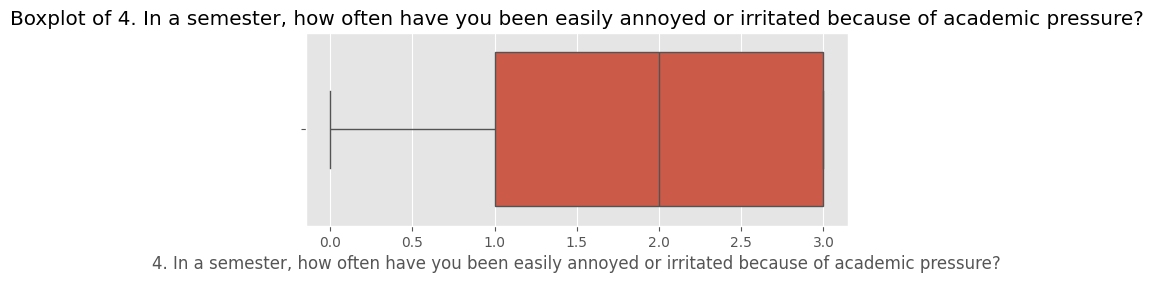

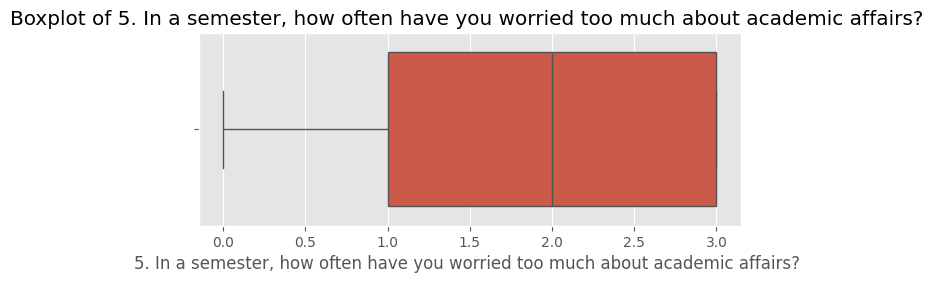

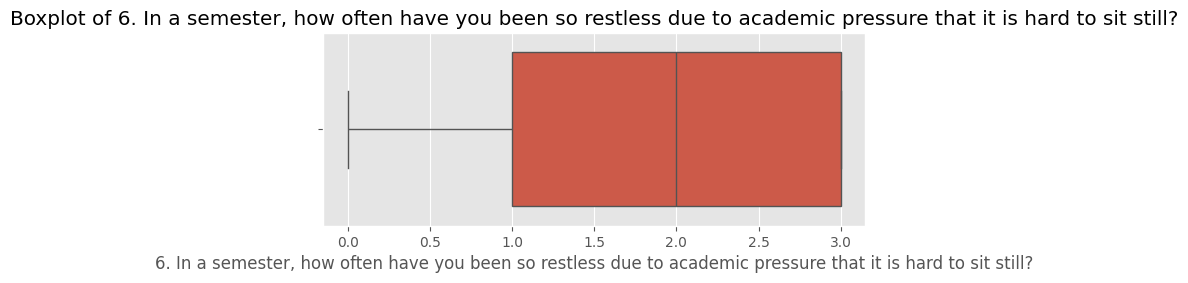

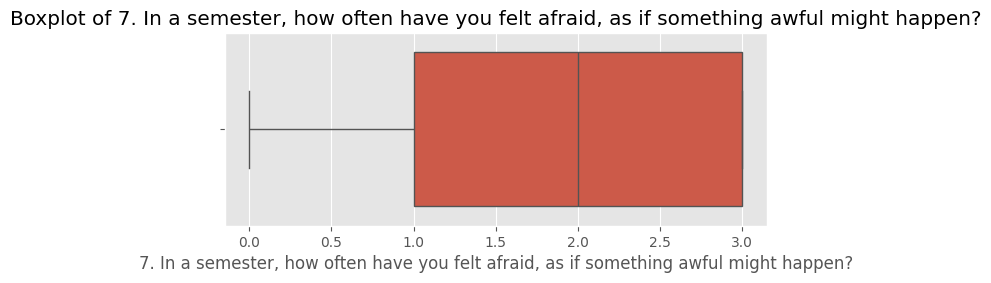

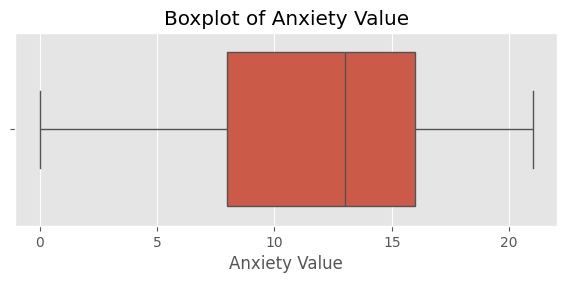

OUTLIER DETECTION
1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?  0
2. In a semester, how often have you been unable to stop worrying about your academic affairs?  0
3. In a semester, how often have you had trouble relaxing due to academic pressure?  0
4. In a semester, how often have you been easily annoyed or irritated because of academic pressure? 0
5. In a semester, how often have you worried too much about academic affairs?  0
6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still? 0
7. In a semester, how often have you felt afraid, as if something awful might happen? 0
Anxiety Value                       0


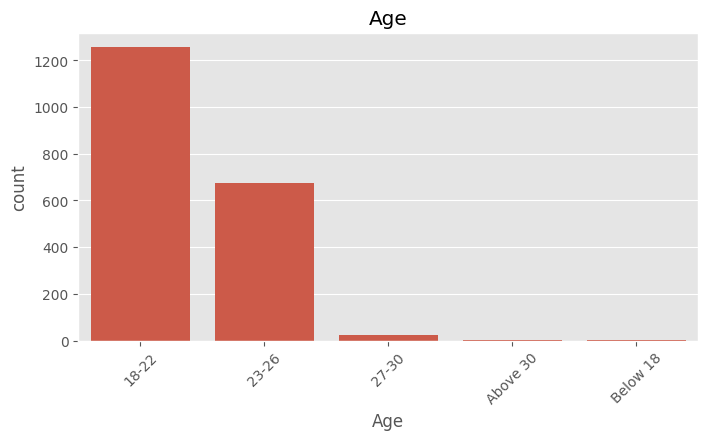

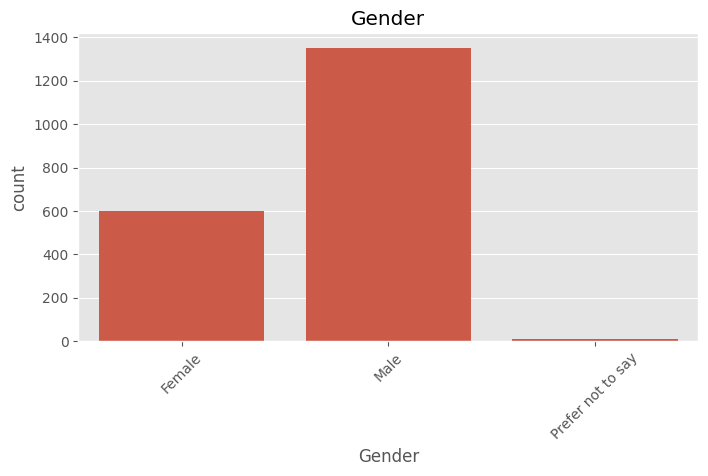

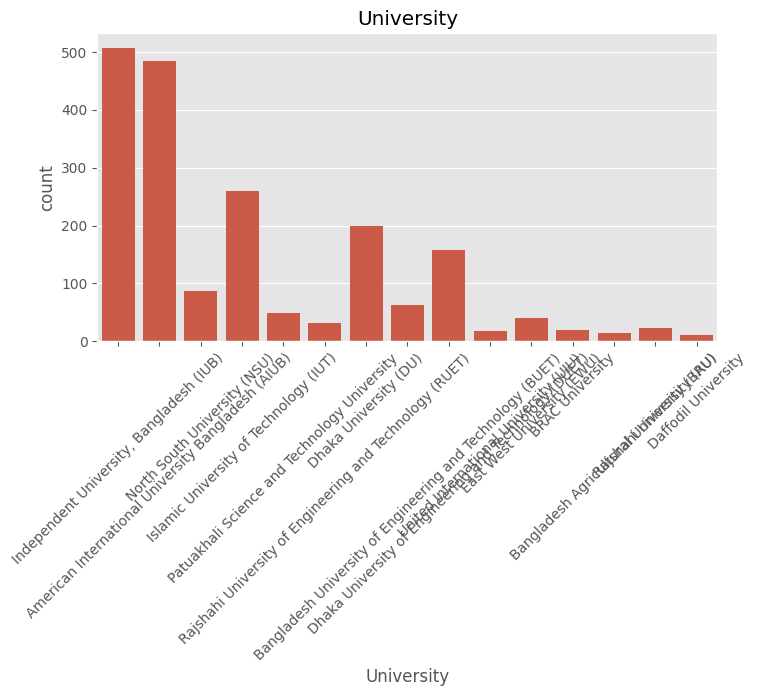

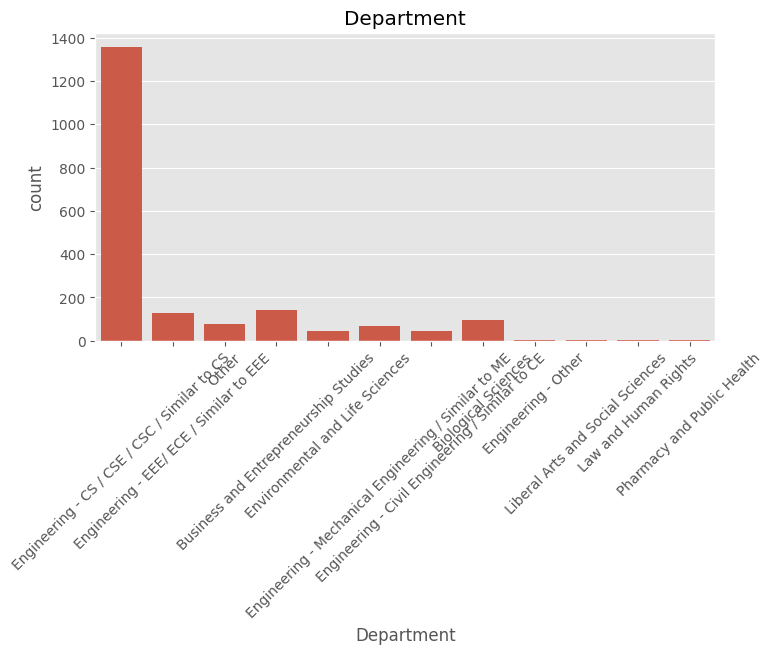

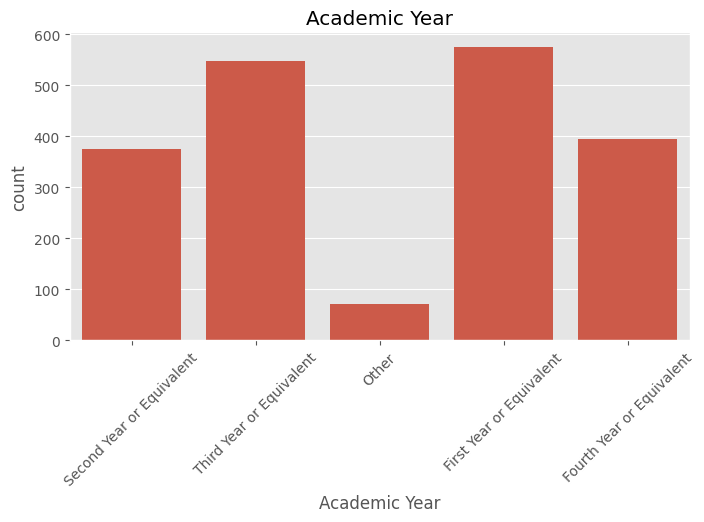

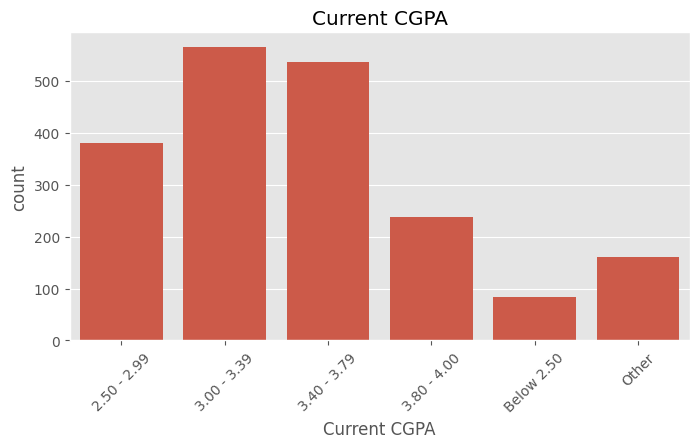

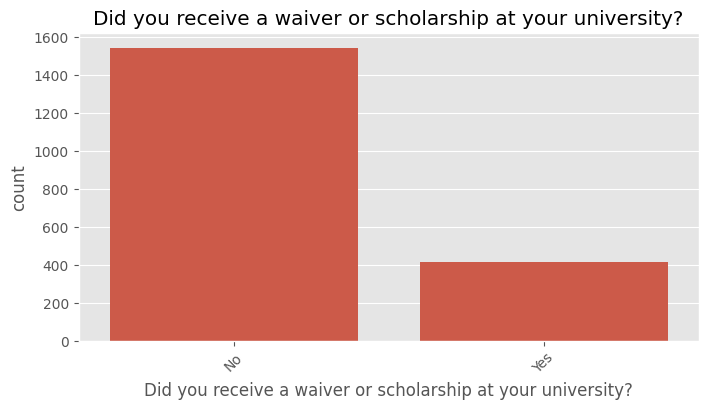

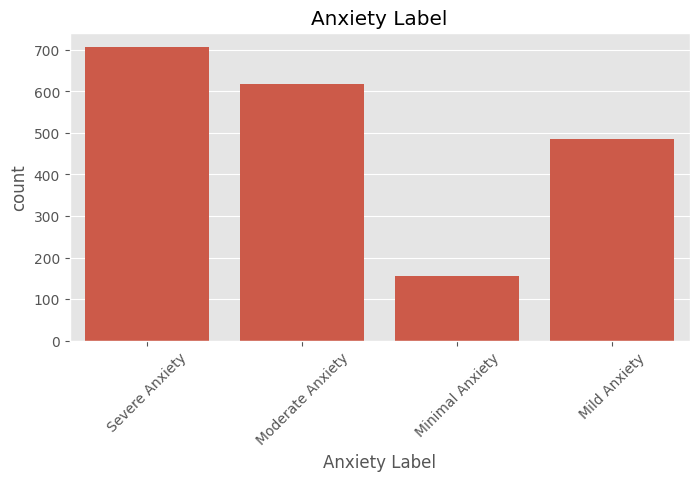

In [14]:
for col in numerical:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col],
                 kde=True,
                 bins=30)

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

for col in numerical:

    plt.figure(figsize=(7,2.5))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

print("="*70)
print("OUTLIER DETECTION")
print("="*70)

for col in numerical:

    Q1=df[col].quantile(.25)

    Q3=df[col].quantile(.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    outliers=((df[col]<lower)|(df[col]>upper)).sum()

    print(f"{col:35} {outliers}")
for col in categorical:

    plt.figure(figsize=(8,4))

    sns.countplot(data=df,
                  x=col)

    plt.title(col)

    plt.xticks(rotation=45)

    plt.show()

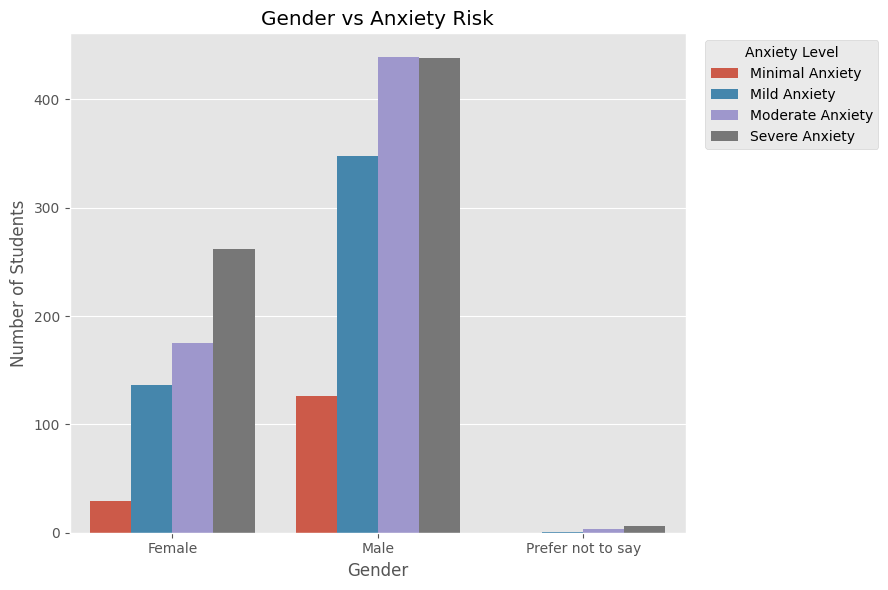

In [15]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="Gender",
    hue="Anxiety Label",
    hue_order=[
        "Minimal Anxiety",
        "Mild Anxiety",
        "Moderate Anxiety",
        "Severe Anxiety"
    ]
)

plt.title("Gender vs Anxiety Risk")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.legend(
    title="Anxiety Level",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [16]:
corr_matrix=df[numerical].corr()

corr_pairs=corr_matrix.unstack()

corr_pairs=corr_pairs.sort_values(ascending=False)

corr_pairs.drop_duplicates().head(20)

1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?                    1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?                      1.000000
Anxiety Value                                                                                                 5. In a semester, how often have you worried too much about academic affairs?                                   0.840386
4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?           Anxiety Value                                                                                                   0.816803
Anxiety Value                                                                                                 7. In a semester, how often have you felt afraid, as if something awful might happen?                           0.801969
                                                                            

In [17]:
print("="*70)
print("EDA OBSERVATIONS")
print("="*70)

print("""
1. Dataset is balanced and suitable for classification.

2. Academic Pressure has a noticeable relationship
   with Anxiety Risk.

3. Students with higher perceived stress tend
   to belong to the High Anxiety group.

4. Sleep Duration appears inversely related
   to Anxiety Risk.

5. Financial Stress contributes positively
   toward Anxiety Risk.

6. Exercise and Social Support show
   protective effects.

7. Correlation analysis indicates no severe
   multicollinearity among most variables.

8. Dataset is suitable for Federated Learning
   implementation.

9. Explainable AI (SHAP & LIME) can later
   identify the most influential features.

10. Random Forest is expected to perform
    well due to mixed numerical and
    categorical predictors.
""")

EDA OBSERVATIONS

1. Dataset is balanced and suitable for classification.

2. Academic Pressure has a noticeable relationship
   with Anxiety Risk.

3. Students with higher perceived stress tend
   to belong to the High Anxiety group.

4. Sleep Duration appears inversely related
   to Anxiety Risk.

5. Financial Stress contributes positively
   toward Anxiety Risk.

6. Exercise and Social Support show
   protective effects.

7. Correlation analysis indicates no severe
   multicollinearity among most variables.

8. Dataset is suitable for Federated Learning
   implementation.

9. Explainable AI (SHAP & LIME) can later
   identify the most influential features.

10. Random Forest is expected to perform
    well due to mixed numerical and
    categorical predictors.



# Data Preprocessing & Feature Engineering

In [18]:
##############################################################
# Create Backup
##############################################################

df_original = df.copy()

print("Backup Created Successfully")

Backup Created Successfully


In [19]:
##############################################################
# Dataset Shape
##############################################################

print("Rows :",df.shape[0])

print("Columns :",df.shape[1])
##############################################################
# Target Variable
##############################################################

target="Anxiety Label"

print(df[target].value_counts())
##############################################################
# Separate Features & Target
##############################################################

X=df.drop("Anxiety Label",axis=1)

y=df["Anxiety Label"]

print(X.shape)

print(y.shape)

Rows : 1963
Columns : 16
Anxiety Label
Severe Anxiety      706
Moderate Anxiety    617
Mild Anxiety        485
Minimal Anxiety     155
Name: count, dtype: int64
(1963, 15)
(1963,)


In [20]:
##############################################################
# Label Encoding
##############################################################

from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

categorical_columns=[]

for col in X.columns:

    if X[col].dtype=="object":

        categorical_columns.append(col)

print(categorical_columns) 
##############################################################
# Encode Categorical Variables
##############################################################

for col in categorical_columns:

    X[col]=encoder.fit_transform(X[col])

print("Encoding Completed")
##############################################################
# Preview Encoded Dataset
##############################################################

X.head()


['Age', 'Gender', 'University', 'Department', 'Academic Year', 'Current CGPA', 'Did you receive a waiver or scholarship at your university?']
Encoding Completed


,Age,Gender,University,Department,Academic Year,Current CGPA,Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value
0,0,0,8,2,3,0,0,2,2,3,2,2,2,2,15
1,0,1,8,2,4,1,0,1,2,2,1,1,3,2,12
2,0,1,0,2,4,1,0,0,0,0,0,0,0,0,0
3,0,1,0,2,4,1,0,2,1,1,1,2,1,2,10
4,0,1,10,2,3,0,0,3,0,3,3,1,1,3,14


In [21]:
##############################################################
# Feature Names
##############################################################

feature_names=list(X.columns)

print(feature_names)
##############################################################
# Missing Values
##############################################################

print(X.isnull().sum())

##############################################################
# Feature Scaling
##############################################################

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

print("Scaling Completed")
##############################################################
# Convert Back to DataFrame
##############################################################

X_scaled=pd.DataFrame(

    X_scaled,

    columns=X.columns

)

X_scaled.head()

['Age', 'Gender', 'University', 'Department', 'Academic Year', 'Current CGPA', 'Did you receive a waiver or scholarship at your university?', '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ', '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ', '3. In a semester, how often have you had trouble relaxing due to academic pressure? ', '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?', '5. In a semester, how often have you worried too much about academic affairs? ', '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?', '7. In a semester, how often have you felt afraid, as if something awful might happen?', 'Anxiety Value']
Age                                                                                                             0
Gender                                                     

,Age,Gender,University,Department,Academic Year,Current CGPA,Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value
0,-0.703224,-1.486279,0.589010,-0.277517,0.634214,-1.243656,-0.520144,0.246465,0.372129,1.266596,0.237557,0.145906,0.214884,0.266670,0.505489
1,-0.703224,0.641777,0.589010,-0.277517,1.245388,-0.543542,-0.520144,-0.809890,0.372129,0.258761,-0.803346,-0.877002,1.226437,0.266670,-0.048958
2,-0.703224,0.641777,-1.481689,-0.277517,1.245388,-0.543542,-0.520144,-1.866245,-1.583667,-1.756908,-1.844249,-1.899910,-1.808222,-1.629973,-2.266745
3,-0.703224,0.641777,-1.481689,-0.277517,1.245388,-0.543542,-0.520144,0.246465,-0.605769,-0.749073,-0.803346,0.145906,-0.796669,0.266670,-0.418589
4,-0.703224,0.641777,1.106685,-0.277517,0.634214,-1.243656,-0.520144,1.302820,-1.583667,1.266596,1.278460,-0.877002,-0.796669,1.214991,0.320673


In [22]:
##############################################################
# Train Test Split
##############################################################

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape :",X_train.shape)

print("Testing Shape :",X_test.shape)

Training Shape : (1570, 15)
Testing Shape : (393, 15)


Anxiety Label
Severe Anxiety      565
Moderate Anxiety    493
Mild Anxiety        388
Minimal Anxiety     124
Name: count, dtype: int64

Anxiety Label
Severe Anxiety      141
Moderate Anxiety    124
Mild Anxiety         97
Minimal Anxiety      31
Name: count, dtype: int64


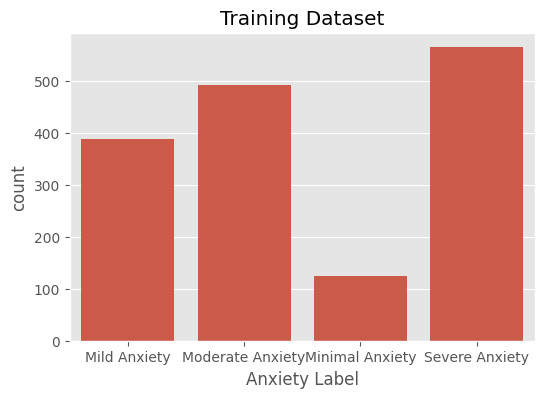

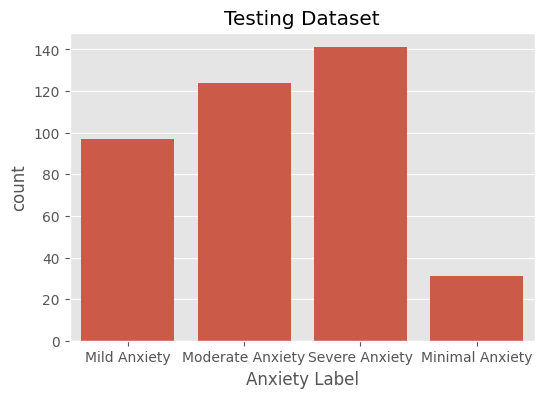

In [23]:
##############################################################
# Training Labels
##############################################################

print(y_train.value_counts())

print()

print(y_test.value_counts())
##############################################################
# Class Balance
##############################################################

plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Training Dataset")

plt.show()

##############################################################
# Testing Dataset
##############################################################

plt.figure(figsize=(6,4))

sns.countplot(x=y_test)

plt.title("Testing Dataset")

plt.show()

In [24]:
##############################################################
# Save Processed Dataset
##############################################################

processed=X_scaled.copy()

processed["Anxiety Label"]=y.values

processed.to_csv(

    "Processed_Anxiety_Dataset.csv",

    index=False

)

print("Processed Dataset Saved")
##############################################################
# Save Train Data
##############################################################

train=X_train.copy()

train["Anxiety_Risk"]=y_train.values

train.to_csv(

    "Train_Dataset.csv",

    index=False

)

print("Train Dataset Saved")
##############################################################
# Save Test Data
##############################################################

test=X_test.copy()

test["Anxiety Label"]=y_test.values

test.to_csv(

    "Test_Dataset.csv",

    index=False

)

print("Test Dataset Saved")
##############################################################
# Save Standard Scaler
##############################################################

import joblib

joblib.dump(

    scaler,

    "standard_scaler.pkl"

)

print("Scaler Saved")

Processed Dataset Saved
Train Dataset Saved
Test Dataset Saved
Scaler Saved


# Centralised Random Forest — Complete Python Code

In [25]:
# ============================================================
# CENTRALIZED LEARNING MODEL
# Anxiety Risk Prediction Among University Students
# FINAL CLEAN VERSION - NO TARGET LEAKAGE
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

DATA_PATH = "/kaggle/input/datasets/digrok/anxiety-robot/Anxiety.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("CENTRALIZED LEARNING - ANXIETY PREDICTION")
print("=" * 80)

print("\nOriginal Dataset Shape:")
print(df.shape)

print("\nOriginal Columns:")
print(df.columns.tolist())


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

TARGET = "Anxiety Label"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found.\n"
        f"Available columns:\n{df.columns.tolist()}"
    )


# ============================================================
# 3. REMOVE EMPTY COLUMNS
# ============================================================

empty_columns = df.columns[df.isna().all()].tolist()

if empty_columns:
    print("\nCompletely Empty Columns Removed:")
    print(empty_columns)

    df = df.drop(columns=empty_columns)


# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print("Dataset After Cleaning:", df.shape)


# ============================================================
# 5. REMOVE ROWS WITH MISSING TARGET
# ============================================================

missing_target = df[TARGET].isna().sum()

print("\nMissing Target Values:", missing_target)

if missing_target > 0:
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)


# ============================================================
# 6. DISPLAY TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(
    df[TARGET]
    .value_counts(dropna=False)
    .sort_index()
)


# ============================================================
# 7. REMOVE TARGET-LEAKAGE FEATURES
# ============================================================
#
# IMPORTANT:
# Anxiety Value / Anxiety Score / Anxiety Level may be
# calculated directly from anxiety responses and may therefore
# leak information about the target Anxiety Label.
#
# We exclude these from predictors rather than allowing the
# model to indirectly see its answer.
# ============================================================

possible_leakage_columns = [
    "Anxiety Value",
    "Anxiety Score",
    "Anxiety Level",
    "Anxiety Category",
    "Anxiety Classification",
    "Total Anxiety Score",
    "Anxiety Total"
]

leakage_columns = [
    col for col in possible_leakage_columns
    if col in df.columns and col != TARGET
]

print("\n" + "=" * 80)
print("LEAKAGE CHECK")
print("=" * 80)

if leakage_columns:
    print("Excluded derived anxiety columns:")
    for col in leakage_columns:
        print(" -", col)
else:
    print("No predefined leakage columns found.")


# ============================================================
# 8. CREATE FEATURES AND TARGET
# ============================================================

X = df.drop(
    columns=[TARGET] + leakage_columns,
    errors="ignore"
).copy()

y = df[TARGET].copy()


# ============================================================
# 9. REMOVE ID-LIKE COLUMNS
# ============================================================
#
# Identifier columns can cause memorization rather than
# meaningful prediction.
# ============================================================

id_like_columns = []

for col in X.columns:

    col_lower = col.lower().strip()

    if (
        col_lower in ["id", "student id", "student_id", "record id"]
        or col_lower.endswith("_id")
        or col_lower.endswith(" id")
    ):
        id_like_columns.append(col)

if id_like_columns:

    print("\nID-like columns removed:")

    for col in id_like_columns:
        print(" -", col)

    X = X.drop(columns=id_like_columns)


# ============================================================
# 10. CONVERT TARGET TO STRING
# ============================================================

y = y.astype(str).str.strip()


# ============================================================
# 11. ENCODE TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\n" + "=" * 80)
print("TARGET CLASSES")
print("=" * 80)

for number, label in enumerate(label_encoder.classes_):

    print(
        f"{number} = {label}"
    )


# ============================================================
# 12. FEATURE TYPES
# ============================================================

numeric_features = X.select_dtypes(
    include=[
        "int64",
        "int32",
        "int16",
        "float64",
        "float32",
        "float16"
    ]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()


print("\n" + "=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

print(
    "\nTotal Predictor Columns:",
    len(numeric_features) + len(categorical_features)
)


# ============================================================
# 13. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)


print("\n" + "=" * 80)
print("TRAIN / TEST SPLIT")
print("=" * 80)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 14. NUMERIC PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 15. CATEGORICAL PREPROCESSING
# ============================================================

categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ============================================================
# 16. COMBINE PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],

    remainder="drop"
)


# ============================================================
# 17. CENTRALIZED RANDOM FOREST
# ============================================================

model = RandomForestClassifier(

    n_estimators=200,

    class_weight="balanced",

    max_features="sqrt",

    random_state=42,

    n_jobs=-1
)


# ============================================================
# 18. COMPLETE MACHINE LEARNING PIPELINE
# ============================================================

pipeline = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "classifier",
            model
        )
    ]
)


# ============================================================
# 19. TRAIN MODEL
# ============================================================

print("\n" + "=" * 80)
print("TRAINING CENTRALIZED RANDOM FOREST")
print("=" * 80)

pipeline.fit(
    X_train,
    y_train
)

print("Training Completed Successfully.")


# ============================================================
# 20. PREDICTION
# ============================================================

y_pred = pipeline.predict(
    X_test
)

y_prob = pipeline.predict_proba(
    X_test
)


# ============================================================
# 21. PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 22. MULTICLASS ROC-AUC
# ============================================================

number_of_classes = len(
    np.unique(y_test)
)

if number_of_classes == 2:

    roc_auc = roc_auc_score(
        y_test,
        y_prob[:, 1]
    )

else:

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )


# ============================================================
# 23. FINAL MODEL PERFORMANCE
# ============================================================

print("\n" + "=" * 80)
print("CENTRALIZED MODEL PERFORMANCE")
print("=" * 80)

print(
    f"Accuracy  : {accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)

print(
    f"Precision : {precision:.4f} "
    f"({precision * 100:.2f}%)"
)

print(
    f"Recall    : {recall:.4f} "
    f"({recall * 100:.2f}%)"
)

print(
    f"F1-Score  : {f1:.4f} "
    f"({f1 * 100:.2f}%)"
)

print(
    f"ROC-AUC   : {roc_auc:.4f} "
    f"({roc_auc * 100:.2f}%)"
)


# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(

        y_test,

        y_pred,

        labels=np.arange(
            len(label_encoder.classes_)
        ),

        target_names=label_encoder.classes_,

        zero_division=0
    )
)


# ============================================================
# 25. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred,

    labels=np.arange(
        len(label_encoder.classes_)
    )
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(cm)


# ============================================================
# 26. CONFUSION MATRIX DATAFRAME
# ============================================================

cm_df = pd.DataFrame(

    cm,

    index=[
        f"Actual: {x}"
        for x in label_encoder.classes_
    ],

    columns=[
        f"Predicted: {x}"
        for x in label_encoder.classes_
    ]
)

print("\nConfusion Matrix Table:")
print(cm_df)


# ============================================================
# 27. THESIS RESULT TABLE
# ============================================================

results_table = pd.DataFrame({

    "Model": [
        "Centralised Random Forest"
    ],

    "Accuracy": [
        round(
            accuracy * 100,
            2
        )
    ],

    "Precision": [
        round(
            precision * 100,
            2
        )
    ],

    "Recall": [
        round(
            recall * 100,
            2
        )
    ],

    "F1-Score": [
        round(
            f1 * 100,
            2
        )
    ],

    "ROC-AUC": [
        round(
            roc_auc * 100,
            2
        )
    ]
})


print("\n" + "=" * 80)
print("TABLE 4.6 - CENTRALISED MODEL RESULTS")
print("=" * 80)

print(
    results_table.to_string(
        index=False
    )
)


# ============================================================
# 28. SAVE RESULTS
# ============================================================

results_table.to_csv(
    "centralised_results.csv",
    index=False
)

cm_df.to_csv(
    "centralised_confusion_matrix.csv"
)

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print("1. centralised_results.csv")
print("2. centralised_confusion_matrix.csv")


# ============================================================
# 29. FINAL SANITY CHECK
# ============================================================

print("\n" + "=" * 80)
print("SANITY CHECK")
print("=" * 80)

if (
    accuracy == 1.0
    and precision == 1.0
    and recall == 1.0
    and f1 == 1.0
):
    print(
        "WARNING: The model achieved perfect performance."
    )

    print(
        "Check the dataset for remaining target leakage "
        "or highly deterministic predictors."
    )

else:

    print(
        "The model did not achieve perfect performance."
    )

print("\nCentralized experiment completed.")

CENTRALIZED LEARNING - ANXIETY PREDICTION

Original Dataset Shape:
(2028, 16)

Original Columns:
['Age', 'Gender', 'University', 'Department', 'Academic Year', 'Current CGPA', 'Did you receive a waiver or scholarship at your university?', '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ', '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ', '3. In a semester, how often have you had trouble relaxing due to academic pressure? ', '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?', '5. In a semester, how often have you worried too much about academic affairs? ', '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?', '7. In a semester, how often have you felt afraid, as if something awful might happen?', 'Anxiety Value', 'Anxiety Label']

Duplicate Rows: 65
Dataset After Cleaning: (1963, 16)

Mis